Enhanced BPBO for Test Data Generation
Population Size: 50
Max Iterations: 500
Finding Factor (Pi): 0.7
Fitness Weights: α=0.6, β=0.15, γ=0.25
Iter 0: Best Fitness = 0.5946, Coverage = 3/4 paths

✓ All 4 paths covered at iteration 7!

FINAL RESULTS
Best Fitness: 0.8132
Paths Covered: 4/4
Best Test Case: [1 1 1]
Converged at: 7 generations


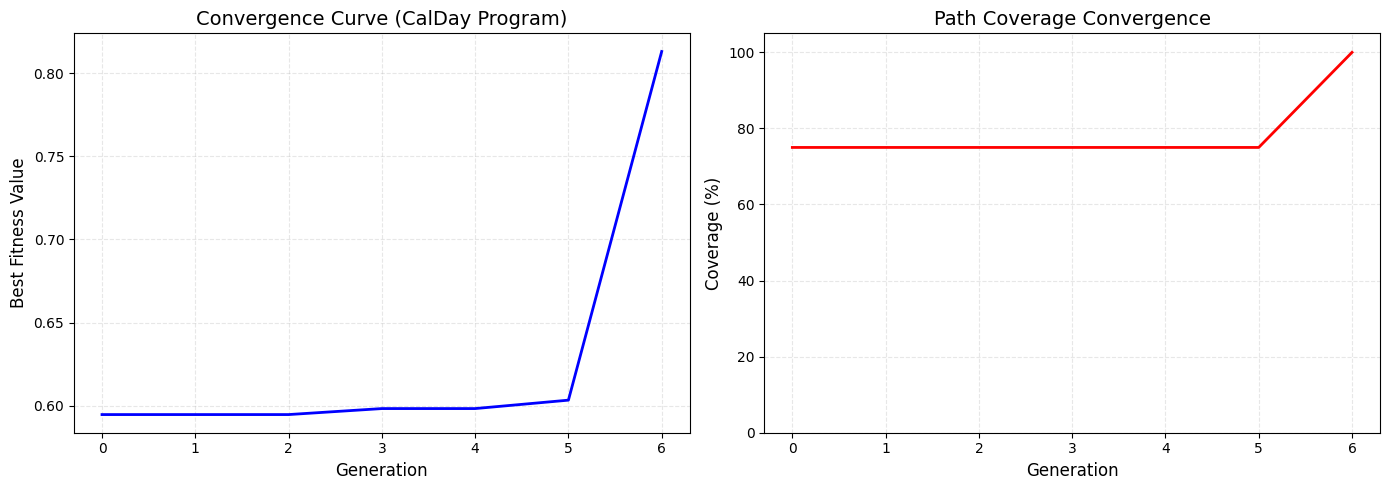


EXPERIMENT SUMMARY
Best Test Case Found: [1 1 1]
Path Coverage: 4/4 paths
Path Distribution: {2: 97, 1: 204, 3: 48, 4: 1}
Convergence Generations: 7


In [1]:
# ============================================
# Enhanced BPBO for Test Data Generation
# Proof of Concept Implementation
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. Program Under Test (TriangleType)
# ============================================

def triangle_type(a, b, c):
    """
    Triangle classification program.
    Returns the path ID (1-4) and the classification result.
    """
    # Validate inputs
    if a <= 0 or b <= 0 or c <= 0:
        return 1, "Invalid (negative/zero side)"

    # Check triangle inequality
    if a + b <= c or a + c <= b or b + c <= a:
        return 1, "Invalid (inequality)"

    # Classify triangle
    if a == b and b == c:
        return 4, "Equilateral"
    elif a == b or b == c or a == c:
        return 3, "Isosceles"
    else:
        return 2, "Scalene"


def evaluate_test_case(test_case):
    """
    Run a test case on the program and return the executed path.
    """
    a, b, c = test_case
    return triangle_type(a, b, c)[0]  # Return path ID only


# ============================================
# 2. Enhanced BPBO Algorithm
# ============================================

class EnhancedBPBO:
    def __init__(self, pop_size=50, max_iter=500, pi=0.7, alpha=0.60, beta=0.15, gamma=0.25):
        """
        Enhanced BPBO for Test Data Generation.

        Parameters:
        - pop_size: Population size (N)
        - max_iter: Maximum iterations (generations)
        - pi: Finding factor (probability of hunting)
        - alpha, beta, gamma: Fitness function weights
        """
        self.pop_size = pop_size
        self.max_iter = max_iter
        self.pi = pi
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        # Search space bounds for TriangleType: a,b,c in [1, 20]
        self.lb = np.array([1, 1, 1])
        self.ub = np.array([20, 20, 20])

        # Track best solution
        self.best_fitness_history = []
        self.best_solution = None
        self.best_fitness = -np.inf
        self.coverage_history = []

    def initialize_population(self):
        """Initialize population randomly within bounds."""
        population = []
        for _ in range(self.pop_size):
            individual = self.lb + np.random.rand(3) * (self.ub - self.lb)
            individual = np.round(individual).astype(int)  # Integer inputs
            population.append(individual)
        return np.array(population)

    def compute_coverage(self, individual, path_map):
        """Coverage score C(X) - Equation (3)."""
        path_id = evaluate_test_case(individual)
        total_paths = 4  # TriangleType has 4 paths
        covered_paths = len(set(path_map.keys()))
        return covered_paths / total_paths if total_paths > 0 else 0

    def compute_specificity(self, individual, path_map):
        """Specificity score S(X) - Equation (4)."""
        path_id = evaluate_test_case(individual)
        freq = path_map.get(path_id, 0)
        return 1.0 / (1.0 + freq)

    def compute_diversity(self, individual, population):
        """Diversity score D(X) - Equation (5)."""
        if len(population) <= 1:
            return 0.5  # Default diversity

        total_distance = 0
        for other in population:
            if np.array_equal(individual, other):
                continue
            # Euclidean distance
            dist = np.linalg.norm(np.array(individual) - np.array(other))
            total_distance += dist

        # Normalize by maximum possible distance (sqrt(3) * 19 ≈ 32.9)
        max_distance = np.sqrt(3) * 19
        return total_distance / ((len(population) - 1) * max_distance)

    def fitness(self, individual, population, path_map):
        """Composite fitness function F(X) - Equation (2)."""
        C = self.compute_coverage(individual, path_map)
        S = self.compute_specificity(individual, path_map)
        D = self.compute_diversity(individual, population)

        F = self.alpha * C + self.beta * S + self.gamma * D
        return F, C, S, D

    def update_individual_hunting(self, individual, prey, k1):
        """Individual hunting (Exploitation) - Equation (6)."""
        new_individual = individual + np.random.rand() * (prey - k1 * individual)
        return new_individual

    def update_cooperative_hunting(self, individual, prey, mean_pos, k2):
        """Cooperative hunting (Exploration) - Equation (7)."""
        new_individual = mean_pos + np.random.rand() * (prey - k2 * mean_pos)
        return new_individual

    def update_competition(self, individual, worst, k3):
        """Competition phase - attacking weak prey."""
        new_individual = individual + np.random.rand() * (individual - k3 * worst)
        return new_individual

    def update_relocation(self):
        """Relocation phase - escape local optima."""
        return self.lb + np.random.rand(3) * (self.ub - self.lb)

    def clamp(self, individual):
        """Clamp individual to bounds and round to integers."""
        individual = np.clip(individual, self.lb, self.ub)
        return np.round(individual).astype(int)

    def run(self, verbose=True):
        """Main BPBO optimization loop."""
        # Step 1: Initialize population
        population = self.initialize_population()
        path_map = {}
        best_individual = None
        best_fitness = -np.inf

        if verbose:
            print("=" * 60)
            print("Enhanced BPBO for Test Data Generation")
            print("=" * 60)
            print(f"Population Size: {self.pop_size}")
            print(f"Max Iterations: {self.max_iter}")
            print(f"Finding Factor (Pi): {self.pi}")
            print(f"Fitness Weights: α={self.alpha}, β={self.beta}, γ={self.gamma}")
            print("=" * 60)

        for iteration in range(self.max_iter):
            # Evaluate all individuals
            fitness_values = []
            for individual in population:
                path_id = evaluate_test_case(individual)
                path_map[path_id] = path_map.get(path_id, 0) + 1

            # Compute fitness for each individual
            new_population = []
            for i, individual in enumerate(population):
                F, C, S, D = self.fitness(individual, population, path_map)
                fitness_values.append((F, individual, C, S, D))

            # Find best and worst
            fitness_values.sort(key=lambda x: x[0], reverse=True)
            best_fitness_current = fitness_values[0][0]
            best_individual_current = fitness_values[0][1]
            worst_individual = fitness_values[-1][1]

            if best_fitness_current > best_fitness:
                best_fitness = best_fitness_current
                best_individual = best_individual_current.copy()

            # Update prey (global best)
            prey = best_individual_current
            mean_pos = np.mean(population, axis=0)

            # Store history
            self.best_fitness_history.append(best_fitness)
            total_paths = 4
            covered = len(set(path_map.keys()))
            self.coverage_history.append(covered / total_paths * 100)

            if verbose and iteration % 50 == 0:
                print(f"Iter {iteration}: Best Fitness = {best_fitness:.4f}, "
                      f"Coverage = {len(set(path_map.keys()))}/4 paths")

            # Phase 4: Update positions (BPBO hunting strategies)
            new_population = []
            for i, individual in enumerate(population):
                rand_val = np.random.rand()

                if rand_val < self.pi:
                    # Hunting phase (individual or cooperative)
                    if np.random.rand() < 0.5:
                        # Individual hunting (exploitation)
                        k1 = np.random.choice([1, 2])
                        new_ind = self.update_individual_hunting(individual, prey, k1)
                    else:
                        # Cooperative hunting (exploration)
                        k2 = np.random.choice([1, 2])
                        new_ind = self.update_cooperative_hunting(individual, prey, mean_pos, k2)
                else:
                    # Competition or relocation
                    if np.random.rand() < 0.5:
                        # Competition
                        k3 = np.random.choice([1, 2])
                        new_ind = self.update_competition(individual, worst_individual, k3)
                    else:
                        # Relocation
                        new_ind = self.update_relocation()

                # Clamp and round
                new_ind = self.clamp(new_ind)
                new_population.append(new_ind)

            # Update population
            population = np.array(new_population)

            # Greedy selection: keep best if better
            for i in range(self.pop_size):
                F_new, _, _, _ = self.fitness(population[i], population, path_map)
                F_old, _, _, _ = self.fitness(fitness_values[i][1], population, path_map)
                if F_new < F_old:
                    population[i] = fitness_values[i][1].copy()

            # Check convergence
            if len(set(path_map.keys())) >= 4:  # All paths covered
                if verbose:
                    print(f"\n✓ All 4 paths covered at iteration {iteration+1}!")
                break

        if verbose:
            print("\n" + "=" * 60)
            print("FINAL RESULTS")
            print("=" * 60)
            print(f"Best Fitness: {best_fitness:.4f}")
            print(f"Paths Covered: {len(set(path_map.keys()))}/4")
            print(f"Best Test Case: {best_individual}")
            print(f"Converged at: {len(self.best_fitness_history)} generations")
            print("=" * 60)

        self.best_solution = best_individual

        # Return results
        return {
            'best_solution': best_individual,
            'best_fitness': best_fitness,
            'fitness_history': self.best_fitness_history,
            'coverage_history': self.coverage_history,
            'path_map': path_map,
            'generations': len(self.best_fitness_history)
        }


# ============================================
# 3. Run Experiment
# ============================================

def run_experiment():
    # Create Enhanced BPBO instance
    bpbo = EnhancedBPBO(
        pop_size=50,
        max_iter=500,
        pi=0.7,
        alpha=0.60,
        beta=0.15,
        gamma=0.25
    )

    # Run algorithm
    results = bpbo.run(verbose=True)

    # Plot convergence
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Fitness convergence
    ax1.plot(results['fitness_history'], 'b-', linewidth=2)
    ax1.set_xlabel('Generation', fontsize=12)
    ax1.set_ylabel('Best Fitness Value', fontsize=12)
    ax1.set_title('Convergence Curve (CalDay Program)', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.3)

    # Coverage convergence
    ax2.plot(results['coverage_history'], 'r-', linewidth=2)
    ax2.set_xlabel('Generation', fontsize=12)
    ax2.set_ylabel('Coverage (%)', fontsize=12)
    ax2.set_title('Path Coverage Convergence', fontsize=14)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_ylim(0, 105)

    plt.tight_layout()
    plt.savefig('convergence_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print summary
    print("\n" + "=" * 60)
    print("EXPERIMENT SUMMARY")
    print("=" * 60)
    print(f"Best Test Case Found: {results['best_solution']}")
    print(f"Path Coverage: {len(results['path_map'])}/4 paths")
    print(f"Path Distribution: {results['path_map']}")
    print(f"Convergence Generations: {results['generations']}")
    print("=" * 60)

    return results


# ============================================
# 4. Run the Experiment
# ============================================

if __name__ == "__main__":
    results = run_experiment()